## 1. Instalar e importar bibliotecas

In [ ]:
!pip -q install rasterio scikit-image scikit-learn scipy

from pathlib import Path
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from skimage.morphology import remove_small_objects, remove_small_holes, binary_dilation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from scipy.ndimage import distance_transform_edt, uniform_filter
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score
from scipy.ndimage import uniform_filter, distance_transform_edt



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\bielc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Configurações

In [ ]:
BASE_DIR = Path(os.getcwd())
DATA_DIR = Path(BASE_DIR, 'data', 'NTL_LITORAL_SC', 'QGIS_LITORAL', 'RASTER', 'NTL_LITORAL')
RESULTADOS_DIR = Path(BASE_DIR, 'resultados')
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

MOSTRAR_DETALHES = False

if MOSTRAR_DETALHES:
    print("Pasta de dados:", DATA_DIR)
    print("Pasta de resultados:", RESULTADOS_DIR)

## 3. Função auxiliar para salvar arquivos CSV

In [ ]:
def salvar_arquivo_csv(tabela, nome_arquivo):
    caminho_arquivo = RESULTADOS_DIR / f"{nome_arquivo}.csv"
    tabela.to_csv(caminho_arquivo, index=False)
    if MOSTRAR_DETALHES:
        print(f"Arquivo salvo: {caminho_arquivo}")

## 4. Listar os arquivos `.tif`

In [ ]:
padrao_nome_arquivo = re.compile(
    r"VIIRS_NTL_MedianaMensal_(?P<regiao>.+?)_(?P<ano>\d{4})_(?P<mes>\d{2})_reprojetada.*\.tif$"
)

linhas_arquivos = []

for caminho_imagem in DATA_DIR.rglob("*.tif"):
    resultado_nome = padrao_nome_arquivo.search(caminho_imagem.name)

    if resultado_nome is None:
        continue

    regiao = resultado_nome.group("regiao")
    ano = int(resultado_nome.group("ano"))
    mes = int(resultado_nome.group("mes"))

    linhas_arquivos.append({
        "regiao": regiao,
        "ano": ano,
        "mes": mes,
        "data": pd.Timestamp(year=ano, month=mes, day=1),
        "caminho_tif": str(caminho_imagem),
        "possui_aux_xml": caminho_imagem.with_name(caminho_imagem.name + ".aux.xml").exists()
    })

tabela_arquivos = pd.DataFrame(linhas_arquivos)

tabela_arquivos = tabela_arquivos.sort_values(["regiao", "ano", "mes"]).reset_index(drop=True)

if MOSTRAR_DETALHES:
    display(tabela_arquivos.head())
    print("Total de imagens encontradas:", len(tabela_arquivos))

## 5. Funções principais

In [ ]:

# Função para pegar os dados de uma imagem
def ler_imagem_luzes(caminho_tif):
    with rasterio.open(caminho_tif) as imagem_raster:
        imagem_luzes = imagem_raster.read(1).astype("float32")
        valor_sem_dado = imagem_raster.nodata
        transformacao_espacial = imagem_raster.transform
        sistema_referencia = imagem_raster.crs

    mascara_valida = np.isfinite(imagem_luzes)

    if valor_sem_dado is not None:
        mascara_valida = mascara_valida & (imagem_luzes != valor_sem_dado)

    imagem_luzes[~mascara_valida] = np.nan
    return imagem_luzes, transformacao_espacial, sistema_referencia

# Limpa valores extremos e normaliza a imagem de forma logaritmica para visualização
def normalizar_para_visualizacao(imagem_luzes, percentil_maximo=99):
    imagem_visual = imagem_luzes.copy()
    valores_validos = imagem_visual[np.isfinite(imagem_visual)]

    limite_superior = np.nanpercentile(valores_validos, percentil_maximo)
    imagem_visual = np.clip(imagem_visual, 0, limite_superior)
    imagem_visual = np.log1p(imagem_visual)
    return imagem_visual


# Calcula um valor para usar de threshold usando as amostras de uma regiao (não pega todos os valores, só uma parte para agilizar)
def calcular_threshold_regiao(tabela_arquivos_regiao, percentil_threshold=75, limite_amostras_por_imagem=50000):
    amostras_luzes = []

    for linha in tabela_arquivos_regiao.itertuples():
        imagem_luzes, _, _ = ler_imagem_luzes(linha.caminho_tif)
        valores_validos = imagem_luzes[np.isfinite(imagem_luzes)] # Remove NaN, inf, -inf
        valores_positivos = valores_validos[valores_validos > 0] # Remove < 0

        if len(valores_positivos) > limite_amostras_por_imagem:
            indices_amostra = np.random.choice(
                len(valores_positivos),
                size=limite_amostras_por_imagem,
                replace=False
            )
            valores_positivos = valores_positivos[indices_amostra]

        amostras_luzes.append(valores_positivos)

    if len(amostras_luzes) == 0:
        return 0.0

    valores_regiao = np.concatenate(amostras_luzes)
    return float(np.nanpercentile(valores_regiao, percentil_threshold))

# A partir de um threshold gera um array com binário: Pixel iluminado / Apagado
def criar_mascara_area_iluminada(imagem_luzes, threshold_luz):
    mascara_area_iluminada = np.zeros(imagem_luzes.shape, dtype=bool)
    mascara_valida = np.isfinite(imagem_luzes)

    mascara_area_iluminada[mascara_valida] = imagem_luzes[mascara_valida] >= threshold_luz
    mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
    mascara_area_iluminada = remove_small_holes(mascara_area_iluminada, area_threshold=9)

    return mascara_area_iluminada

# transformacao_espacial vem do .tif e tem informações sobre tamanho do pixel e posição na imagem, o sistema_referencia traz
# informações sobre o sistema geográfico usado. Retorna o valor em km² que um pixel representa
def calcular_area_pixel_km2(transformacao_espacial, sistema_referencia):
    if sistema_referencia is not None and sistema_referencia.is_projected:
        area_pixel_m2 = abs(transformacao_espacial.a * transformacao_espacial.e)
        return area_pixel_m2 / 1_000_000

    return 1.0

# Gera o resumo das funções anteriores. Retorna um dicionario com as informações
def extrair_metricas_area_iluminada(imagem_luzes, mascara_area_iluminada, transformacao_espacial, sistema_referencia):
    quantidade_pixels_validos = int(np.isfinite(imagem_luzes).sum())
    quantidade_pixels_iluminados = int(mascara_area_iluminada.sum())
    area_pixel_km2 = calcular_area_pixel_km2(transformacao_espacial, sistema_referencia)

    area_iluminada_km2 = quantidade_pixels_iluminados * area_pixel_km2
    percentual_area_iluminada = (
        quantidade_pixels_iluminados / quantidade_pixels_validos
        if quantidade_pixels_validos > 0 else np.nan
    )

    if quantidade_pixels_iluminados > 0:
        media_luz_area_iluminada = float(np.nanmean(imagem_luzes[mascara_area_iluminada]))
    else:
        media_luz_area_iluminada = np.nan

    return {
        "pixels_validos": quantidade_pixels_validos,
        "pixels_iluminados": quantidade_pixels_iluminados,
        "area_iluminada_km2": area_iluminada_km2,
        "percentual_area_iluminada": percentual_area_iluminada,
        "media_luz_area_iluminada": media_luz_area_iluminada,
        "media_luz_total": float(np.nanmean(imagem_luzes))
    }

def extrair_features_espaciais(imagem_luzes, mascara_area_iluminada):
    """
    Cria variáveis de contexto espacial para ajudar o modelo a prever a expansão nas bordas.
    """
    # 1. Densidade da vizinhança (média de luz em uma janela 5x5 ao redor do pixel)
    # Substitui NaNs por 0 temporariamente para o filtro funcionar bem
    img_sem_nan = np.nan_to_num(imagem_luzes, nan=0.0)
    densidade_vizinhanca = uniform_filter(img_sem_nan, size=5)
    
    # 2. Distância para a área iluminada mais próxima
    # Inverte a máscara: 1 onde é escuro (fundo), 0 onde é iluminado
    mascara_fundo = ~mascara_area_iluminada
    # Calcula a distância em pixels de cada ponto escuro até o ponto iluminado mais próximo
    distancia_borda = distance_transform_edt(mascara_fundo)
    
    return densidade_vizinhanca, distancia_borda

## 6. Calcular um threshold para cada região

In [ ]:
PERCENTIL_THRESHOLD = 60

thresholdes_por_regiao = {}

for regiao in sorted(tabela_arquivos["regiao"].unique()):
    tabela_regiao = tabela_arquivos[tabela_arquivos["regiao"] == regiao]
    threshold_regiao = calcular_threshold_regiao(tabela_regiao, percentil_threshold=PERCENTIL_THRESHOLD)
    thresholdes_por_regiao[regiao] = threshold_regiao
    print(f"{regiao}: threshold = {threshold_regiao:.4f}")

Blumenau: threshold = 3.3853
Criciuma: threshold = 1.0377
Florianopolis: threshold = 2.2147
Joinville: threshold = 0.9488


## 7. Visualizar uma imagem de exemplo

C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

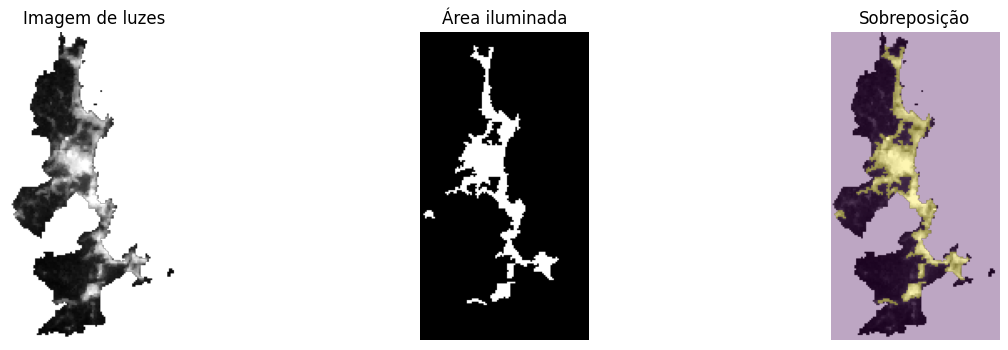

In [ ]:
# Mostra
# 1- Imagem original
# 2- Imagem binarizada
# 3- Sobreposição da original + binarizada

exemplo_arquivo = tabela_arquivos.iloc[0]

imagem_luzes, transformacao_espacial, sistema_referencia = ler_imagem_luzes(exemplo_arquivo.caminho_tif)
imagem_visual = normalizar_para_visualizacao(imagem_luzes)
mascara_area_iluminada = criar_mascara_area_iluminada(
    imagem_luzes,
    threshold_luz=thresholdes_por_regiao[exemplo_arquivo.regiao]
)

if MOSTRAR_DETALHES:
    print("Região:", exemplo_arquivo.regiao)
    print("Data:", exemplo_arquivo.data.date())
    print("Threshold usado:", thresholdes_por_regiao[exemplo_arquivo.regiao])

figura, eixos = plt.subplots(1, 3, figsize=(15, 4))

eixos[0].imshow(imagem_visual, cmap="gray")
eixos[0].set_title("Imagem de luzes")

eixos[1].imshow(mascara_area_iluminada, cmap="gray")
eixos[1].set_title("Área iluminada")

eixos[2].imshow(imagem_visual, cmap="gray")
eixos[2].imshow(mascara_area_iluminada, alpha=0.35)
eixos[2].set_title("Sobreposição")

for eixo in eixos:
    eixo.axis("off")

plt.show()

## 8. Processar todas as imagens

In [ ]:
linhas_metricas = []
total_imagens = len(tabela_arquivos)

for numero_linha, linha in enumerate(tabela_arquivos.itertuples(), start=1):
    porcentagem = 100 * numero_linha / total_imagens
    if MOSTRAR_DETALHES:
        print(f"Processando {numero_linha}/{total_imagens} ({porcentagem:.1f}%): {linha.regiao} {linha.ano}-{linha.mes:02d}")

    imagem_luzes, transformacao_espacial, sistema_referencia = ler_imagem_luzes(linha.caminho_tif)
    threshold_luz = thresholdes_por_regiao[linha.regiao]
    mascara_area_iluminada = criar_mascara_area_iluminada(imagem_luzes, threshold_luz)
    metricas_area = extrair_metricas_area_iluminada(
        imagem_luzes,
        mascara_area_iluminada,
        transformacao_espacial,
        sistema_referencia
    )

    linhas_metricas.append({
        "regiao": linha.regiao,
        "ano": linha.ano,
        "mes": linha.mes,
        "data": linha.data,
        "threshold_luz": threshold_luz,
        **metricas_area
    })

tabela_metricas = pd.DataFrame(linhas_metricas)
tabela_metricas = tabela_metricas.sort_values(["regiao", "data"]).reset_index(drop=True)

display(tabela_metricas.head())

salvar_arquivo_csv(tabela_metricas, "metricas_area_iluminada")

C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

,regiao,ano,mes,data,threshold_luz,pixels_validos,pixels_iluminados,area_iluminada_km2,percentual_area_iluminada,media_luz_area_iluminada,media_luz_total
0,Blumenau,2015,1,2015-01-01,3.385308,5608,1799,422.842213,0.320792,49.505001,16.565205
1,Blumenau,2015,2,2015-02-01,3.385308,5608,1847,434.124273,0.329351,26.262482,9.290390
2,Blumenau,2015,3,2015-03-01,3.385308,5608,1892,444.701204,0.337375,25.285540,9.261672
3,Blumenau,2015,4,2015-04-01,3.385308,5608,1924,452.222578,0.343081,25.931047,9.863873
4,Blumenau,2015,5,2015-05-01,3.385308,5608,1857,436.474702,0.331134,25.279068,9.329413


## 9. Tratamento de outliers

In [ ]:
# Faz a limpeza de ruídos nas imagens em duas etapas (Passo Estatístico + Passo Físico)
def tratar_outliers_area_iluminada(tabela_metricas, janela_mediana=13, fator_limite=2.5):
    tabelas_tratadas = []

    for regiao in sorted(tabela_metricas["regiao"].unique()):
        dados_regiao = tabela_metricas[tabela_metricas["regiao"] == regiao].copy()
        dados_regiao = dados_regiao.sort_values("data").reset_index(drop=True)

        serie_area = dados_regiao["area_iluminada_km2"].astype(float)

        # -------------------------------------------------------------
        # PASSO 1: Filtro Estatístico (Remove picos isolados e ruídos)
        # -------------------------------------------------------------
        mediana_movel = serie_area.rolling(
            window=janela_mediana,
            center=True,
            min_periods=3
        ).median()
        mediana_movel = mediana_movel.bfill().ffill()

        diferenca_mediana = (serie_area - mediana_movel).abs()
        desvio_mediano = np.nanmedian(diferenca_mediana)

        if desvio_mediano == 0 or np.isnan(desvio_mediano):
            outlier_estatistico = pd.Series(False, index=serie_area.index)
        else:
            limite_outlier = fator_limite * 1.4826 * desvio_mediano
            outlier_estatistico = diferenca_mediana > limite_outlier

        # Cria uma série pré-limpa apenas para não "envenenar" a trava física
        serie_pre_limpa = serie_area.copy()
        serie_pre_limpa[outlier_estatistico] = np.nan
        serie_pre_limpa = serie_pre_limpa.interpolate(method='linear').bfill().ffill()

        # -------------------------------------------------------------
        # PASSO 2: Trava Física (Remove anomalias climáticas longas)
        # -------------------------------------------------------------
        # Agora usamos a série *pré-limpa* para calcular o histórico
        # Uma cidade não pode perder 15% de área urbana repentinamente.
        maximo_historico_movel = serie_pre_limpa.cummax()
        outlier_queda_fisica = serie_pre_limpa < (maximo_historico_movel * 0.85)

        # Combina as duas classificações
        dados_regiao["area_outlier"] = outlier_estatistico | outlier_queda_fisica
        
        dados_regiao["area_iluminada_km2_original"] = serie_area
        dados_regiao["area_iluminada_km2_limpa"] = serie_area

        # Remove os outliers reais
        dados_regiao.loc[
            dados_regiao["area_outlier"],
            "area_iluminada_km2_limpa"
        ] = np.nan

        # Interpolação final para a linha suave
        dados_regiao["area_iluminada_km2_limpa"] = (
            dados_regiao["area_iluminada_km2_limpa"]
            .interpolate(method='linear')
            .bfill()
            .ffill()
        )

        tabelas_tratadas.append(dados_regiao)

    return pd.concat(tabelas_tratadas, ignore_index=True)


# Aplica o tratamento de outliers
tabela_metricas_com_outliers = tratar_outliers_area_iluminada(
    tabela_metricas,
    janela_mediana=13,
    fator_limite=2.5
)

# A tabela abaixo será usada nas etapas de gráfico, validação e previsão
tabela_metricas_modelo = tabela_metricas_com_outliers.copy()
tabela_metricas_modelo["area_iluminada_km2"] = tabela_metricas_modelo["area_iluminada_km2_limpa"]

resumo_outliers = (
    tabela_metricas_com_outliers
    .groupby("regiao")["area_outlier"]
    .sum()
    .reset_index()
    .rename(columns={"area_outlier": "quantidade_outliers"})
)

if MOSTRAR_DETALHES:
    display(resumo_outliers)

salvar_arquivo_csv(tabela_metricas_modelo, "metricas_area_iluminada_tratada")

## 10. Gráfico da área iluminada ao longo do tempo

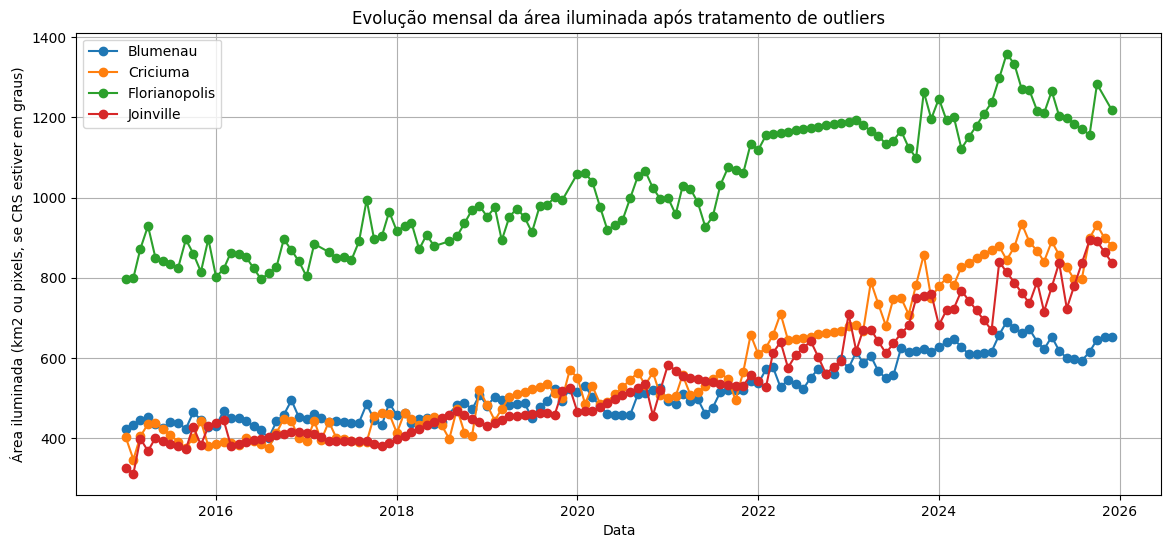

In [ ]:
plt.figure(figsize=(14, 6))

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_regiao = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao]
    plt.plot(dados_regiao["data"], dados_regiao["area_iluminada_km2"], marker="o", label=regiao)

plt.title("Evolução mensal da área iluminada após tratamento de outliers")
plt.xlabel("Data")
plt.ylabel("Área iluminada (km2 ou pixels, se CRS estiver em graus)")
plt.legend()
plt.grid(True)
plt.show()

## 11. Previsão com MLPRegressor


In [ ]:
COLUNAS_ENTRADA = [
    "indice_mes",
    "sazonalidade_seno",
    "sazonalidade_cosseno",
    "area_1_mes_atras",
    "area_2_meses_atras",
    "area_12_meses_atras",
    "indice_tempo"
]

COLUNA_ALVO = "area_iluminada_km2"

# Gera variáveis temporais e features de atraso para o MLPRegressor
# O seno e o cosseno representam a sazonalidade dos meses
# As áreas de meses anteriores ajudam o modelo a considerar a progressão temporal da área iluminada
def adicionar_features_atraso_regiao(dados_regiao):
    dados_regiao = dados_regiao.sort_values("data").copy()
    dados_regiao["indice_tempo"] = np.arange(len(dados_regiao))

    ano_inicial = dados_regiao["ano"].min()
    dados_regiao["indice_mes"] = (dados_regiao["ano"] - ano_inicial) * 12 + dados_regiao["mes"]
    dados_regiao["sazonalidade_seno"] = np.sin(2 * np.pi * dados_regiao["mes"] / 12)
    dados_regiao["sazonalidade_cosseno"] = np.cos(2 * np.pi * dados_regiao["mes"] / 12)

    dados_regiao["area_1_mes_atras"] = dados_regiao["area_iluminada_km2"].shift(1)
    dados_regiao["area_2_meses_atras"] = dados_regiao["area_iluminada_km2"].shift(2)
    dados_regiao["area_12_meses_atras"] = dados_regiao["area_iluminada_km2"].shift(12)

    return dados_regiao

# Retorna uma rede neural simples treinada para uma região
# O TransformedTargetRegressor normaliza também o alvo, reduzindo o risco de explosão da previsão
def treinar_modelo_regiao(dados_regiao):
    dados_modelo = adicionar_features_atraso_regiao(dados_regiao)
    dados_modelo = dados_modelo.dropna(subset=COLUNAS_ENTRADA + [COLUNA_ALVO])

    if len(dados_modelo) < 24:
        return None

    modelo_base = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(16,),
            activation="relu",
            solver="adam",
            alpha=0.01,
            learning_rate_init=0.001,
            max_iter=3000,
            early_stopping=True,
            random_state=42
        )
    )

    modelo_mlp = TransformedTargetRegressor(
        regressor=modelo_base,
        transformer=StandardScaler()
    )

    modelo_mlp.fit(
        dados_modelo[COLUNAS_ENTRADA],
        dados_modelo[COLUNA_ALVO]
    )

    return modelo_mlp


# Pega os valores temporais da região
# Treina o MLPRegressor
# Faz uma previsão para os x meses futuros de forma recursiva
# A cada mês futuro previsto, a previsão entra no histórico para ajudar a prever o mês seguinte
def prever_area_iluminada_regiao(dados_regiao, quantidade_meses_futuros=12):
    dados_regiao = dados_regiao.sort_values("data").copy()
    dados_regiao["indice_tempo"] = np.arange(len(dados_regiao))
    modelo_mlp = treinar_modelo_regiao(dados_regiao)

    if modelo_mlp is None:
        return None, pd.DataFrame()

    ano_inicial = dados_regiao["ano"].min()
    ultima_data = dados_regiao["data"].max()

    historico_previsao = dados_regiao[["data", "ano", "mes", "area_iluminada_km2"]].copy()
    historico_previsao = historico_previsao.sort_values("data").reset_index(drop=True)

    if len(historico_previsao) < 12:
        return None, pd.DataFrame()

    # Limite simples para impedir valores fisicamente absurdos em previsões recursivas
    area_minima_historica = 0.0
    area_maxima_historica = float(dados_regiao[COLUNA_ALVO].max())
    area_maxima_permitida = area_maxima_historica * 1.30

    datas_futuras = pd.date_range(
        start=ultima_data + pd.DateOffset(months=1),
        periods=quantidade_meses_futuros,
        freq="MS"
    )

    linhas_futuras = []

    ultimo_indice_treino = len(dados_regiao) - 1

    for i, data_futura in enumerate(datas_futuras):
        ano_futuro = data_futura.year
        mes_futuro = data_futura.month

        valores_area_historico = historico_previsao["area_iluminada_km2"].astype(float).values

        linha_futura = {
            "data": data_futura,
            "ano": ano_futuro,
            "mes": mes_futuro,
            "indice_mes": (ano_futuro - ano_inicial) * 12 + mes_futuro,
            "sazonalidade_seno": np.sin(2 * np.pi * mes_futuro / 12),
            "sazonalidade_cosseno": np.cos(2 * np.pi * mes_futuro / 12),
            "area_1_mes_atras": valores_area_historico[-1],
            "area_2_meses_atras": valores_area_historico[-2],
            "area_12_meses_atras": valores_area_historico[-12],
            "indice_tempo": ultimo_indice_treino + i + 1
        }

        tabela_linha_futura = pd.DataFrame([linha_futura])
        area_prevista = float(modelo_mlp.predict(tabela_linha_futura[COLUNAS_ENTRADA])[0])

        # Trava simples: evita área negativa e explosões como 1e10 km²
        area_prevista = np.clip(
            area_prevista,
            area_minima_historica,
            area_maxima_permitida
        )

        linha_futura["area_iluminada_prevista_km2"] = float(area_prevista)
        linhas_futuras.append(linha_futura)

        historico_previsao = pd.concat([
            historico_previsao,
            pd.DataFrame([{
                "data": data_futura,
                "ano": ano_futuro,
                "mes": mes_futuro,
                "area_iluminada_km2": float(area_prevista)
            }])
        ], ignore_index=True)

    tabela_futuro = pd.DataFrame(linhas_futuras)

    return modelo_mlp, tabela_futuro


# Executa previsões por região treinando até 2022 e prevendo 2023, 2024 e 2025
linhas_previsoes = []
modelos_por_regiao = {}

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_regiao = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao].copy()
    
    # Filtra os dados de treino até 2022
    dados_treino = dados_regiao[dados_regiao["ano"] <= 2022].copy()
    
    # Prevê 36 meses para frente (cobrir 2023, 2024 e 2025 inteiros)
    modelo_mlp, tabela_futuro = prever_area_iluminada_regiao(dados_treino, quantidade_meses_futuros=36)

    if modelo_mlp is None or len(tabela_futuro) == 0:
        print(f"{regiao}: dados insuficientes para treinar MLPRegressor até 2022.")
        continue

    modelos_por_regiao[regiao] = modelo_mlp
    tabela_futuro["regiao"] = regiao
    linhas_previsoes.append(tabela_futuro)


if len(linhas_previsoes) > 0:
    tabela_previsoes = pd.concat(linhas_previsoes, ignore_index=True)
    display(tabela_previsoes.head())

    salvar_arquivo_csv(tabela_previsoes, "previsao_area_iluminada_mlpregressor")
else:
    tabela_previsoes = pd.DataFrame()
    print("Nenhuma previsão foi gerada.")



,data,ano,mes,indice_mes,sazonalidade_seno,sazonalidade_cosseno,area_1_mes_atras,area_2_meses_atras,area_12_meses_atras,indice_tempo,area_iluminada_prevista_km2,regiao
0,2023-01-01,2023,1,97,0.500000,8.660254e-01,596.303887,559.402149,537.073072,95,579.745199,Blumenau
1,2023-02-01,2023,2,98,0.866025,5.000000e-01,579.745199,596.303887,571.389338,96,600.912281,Blumenau
2,2023-03-01,2023,3,99,1.000000,6.123234e-17,600.912281,579.745199,577.500454,97,584.484912,Blumenau
3,2023-04-01,2023,4,100,0.866025,-5.000000e-01,584.484912,600.912281,526.496140,98,578.919808,Blumenau
4,2023-05-01,2023,5,101,0.500000,-8.660254e-01,578.919808,584.484912,546.239745,99,567.934766,Blumenau


## 12. Visualizar observado x previsto

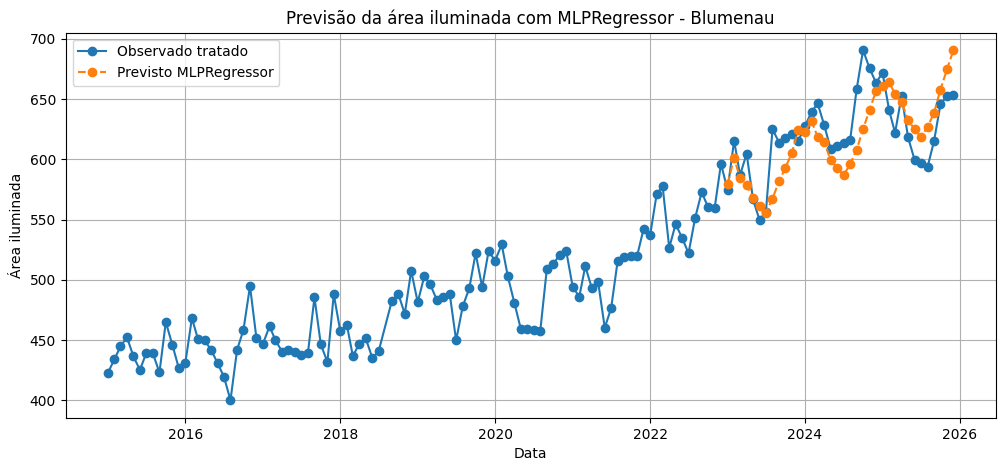

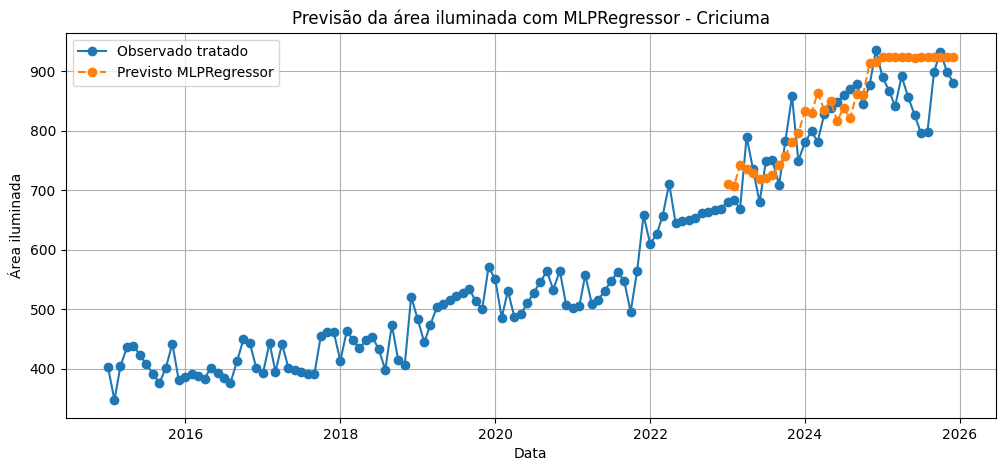

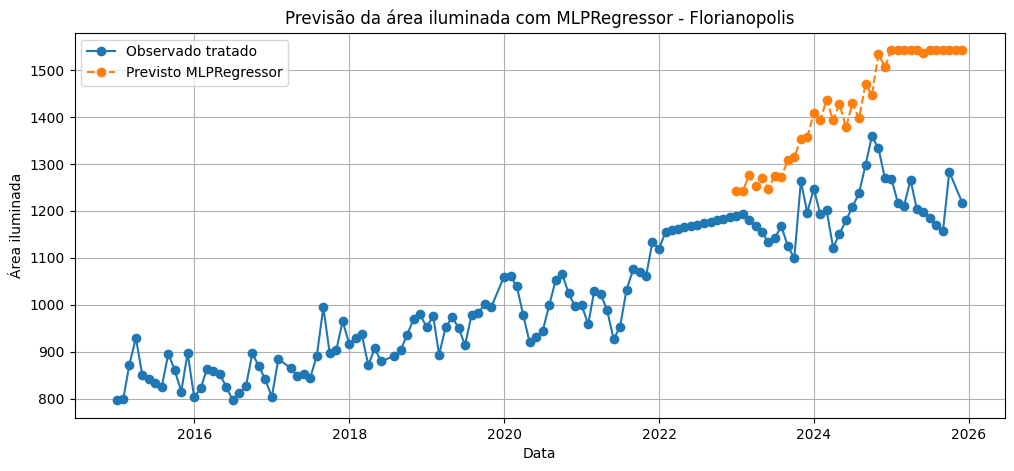

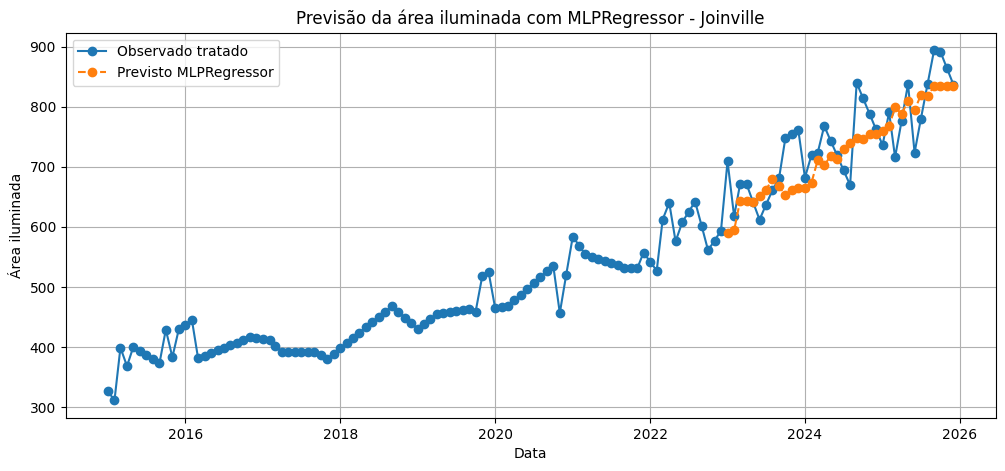

In [ ]:
for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_observados = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao]
    dados_previstos = tabela_previsoes[tabela_previsoes["regiao"] == regiao]

    if len(dados_previstos) == 0:
        print(f"{regiao}: sem previsão para visualizar.")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(
        dados_observados["data"],
        dados_observados["area_iluminada_km2"],
        marker="o",
        label="Observado tratado"
    )
    plt.plot(
        dados_previstos["data"],
        dados_previstos["area_iluminada_prevista_km2"],
        marker="o",
        linestyle="--",
        label="Previsto MLPRegressor"
    )

    plt.title(f"Previsão da área iluminada com MLPRegressor - {regiao}")
    plt.xlabel("Data")
    plt.ylabel("Área iluminada")
    plt.legend()
    plt.grid(True)
    plt.show()

## 13. Validação comparando com o último ano

In [ ]:
# Validação feita treinando com dados até 2022,
# prevendo os anos de 2023 em diante e comparando com os valores observados reais.

linhas_validacao = []
linhas_previsoes_teste = []

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_regiao = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao].copy()
    dados_regiao = dados_regiao.sort_values("data")

    # Atualizado para treinar até 2022 e prever > 2022
    dados_treino = dados_regiao[dados_regiao["ano"] <= 2022].copy()
    dados_teste = dados_regiao[dados_regiao["ano"] > 2022].copy().sort_values("data")

    if len(dados_treino) < 12 or len(dados_teste) == 0:
        print(f"{regiao}: dados insuficientes para validação a partir de 2023.")
        continue

    anos_teste_str = ", ".join(map(str, dados_teste["ano"].unique()))

    modelo_validacao, tabela_teste_prevista = prever_area_iluminada_regiao(
        dados_treino,
        quantidade_meses_futuros=len(dados_teste)
    )

    if modelo_validacao is None or len(tabela_teste_prevista) == 0:
        print(f"{regiao}: não foi possível validar o MLPRegressor.")
        continue

    quantidade_comparacao = min(len(dados_teste), len(tabela_teste_prevista))
    dados_teste_comparacao = dados_teste.iloc[:quantidade_comparacao].copy()
    tabela_teste_prevista = tabela_teste_prevista.iloc[:quantidade_comparacao].copy()

    area_observada = dados_teste_comparacao["area_iluminada_km2"].values
    area_prevista = tabela_teste_prevista["area_iluminada_prevista_km2"].values

    erro_medio_absoluto = mean_absolute_error(area_observada, area_prevista)
    raiz_erro_quadratico_medio = mean_squared_error(area_observada, area_prevista) ** 0.5

    linhas_validacao.append({
        "regiao": regiao,
        "ano_teste": anos_teste_str,
        "erro_medio_absoluto": erro_medio_absoluto,
        "raiz_erro_quadratico_medio": raiz_erro_quadratico_medio
    })

    tabela_teste_prevista["regiao"] = regiao
    tabela_teste_prevista["area_observada_km2"] = area_observada
    # Ajustando datas da tabela prevista para bater com as datas reais de teste
    tabela_teste_prevista["data_real"] = dados_teste_comparacao["data"].values
    linhas_previsoes_teste.append(tabela_teste_prevista)


tabela_validacao = pd.DataFrame(linhas_validacao)

area_media_por_regiao = (
    tabela_metricas_modelo
    .groupby("regiao")["area_iluminada_km2"]
    .mean()
    .reset_index()
    .rename(columns={"area_iluminada_km2": "area_media_iluminada_km2"})
)

if not tabela_validacao.empty:
    tabela_validacao_interpretada = tabela_validacao.merge(
        area_media_por_regiao,
        on="regiao",
        how="left"
    )

    tabela_validacao_interpretada["erro_medio_percentual"] = (
        tabela_validacao_interpretada["erro_medio_absoluto"] /
        tabela_validacao_interpretada["area_media_iluminada_km2"]
    ) * 100

    tabela_validacao_interpretada["erro_rmse_percentual"] = (
        tabela_validacao_interpretada["raiz_erro_quadratico_medio"] /
        tabela_validacao_interpretada["area_media_iluminada_km2"]
    ) * 100

    display(tabela_validacao_interpretada)
    salvar_arquivo_csv(tabela_validacao_interpretada, "validacao_mlpregressor_interpretada")
else:
    print("Nenhuma validação gerada (verifique se há dados a partir de 2023).")


,regiao,ano_teste,erro_medio_absoluto,raiz_erro_quadratico_medio,area_media_iluminada_km2,erro_medio_percentual,erro_rmse_percentual
0,Blumenau,"2023, 2024, 2025",20.742697,25.634813,519.014240,3.996556,4.939135
1,Criciuma,"2023, 2024, 2025",43.481095,52.980117,576.261712,7.545373,9.193760
2,Florianopolis,"2023, 2024, 2025",211.763327,232.746369,1025.037642,20.659078,22.706129
3,Joinville,"2023, 2024, 2025",41.728026,52.015228,540.770341,7.716404,9.618728


## 14. Funções auxiliares e configurações espaciais

In [ ]:
def obter_ultima_imagem_regiao(regiao):
    arquivos_regiao = tabela_arquivos[tabela_arquivos["regiao"] == regiao].sort_values("data")
    return arquivos_regiao.iloc[-1]

COLUNAS_ENTRADA_ESPACIAL = [
    "luz_log",
    "media_luz_vizinhanca",
    "distancia_ate_area_iluminada",
    "linha_normalizada",
    "coluna_normalizada"
]

## 15. Criação das features espaciais por pixel

In [ ]:
# Retorna a média de luz ao redor de um pixel
def calcular_media_vizinhanca(imagem_luzes, tamanho_janela=5):
    imagem_valida = np.isfinite(imagem_luzes)
    imagem_sem_nan = np.nan_to_num(imagem_luzes, nan=0.0, posinf=0.0, neginf=0.0)

    soma_media = uniform_filter(imagem_sem_nan, size=tamanho_janela, mode="nearest")
    contagem_media = uniform_filter(imagem_valida.astype(float), size=tamanho_janela, mode="nearest")

    media_vizinhanca = np.divide(
        soma_media,
        contagem_media,
        out=np.zeros_like(soma_media, dtype=float),
        where=contagem_media > 0
    )

    return media_vizinhanca

from scipy.ndimage import uniform_filter, distance_transform_edt

# 1. Atualizamos a lista de features com o delta_luz_t0
COLUNAS_ENTRADA_ESPACIAL = ["luz_t0", "densidade_vizinhanca_t0", "distancia_borda_t0", "delta_luz_t0"]

def criar_camadas_features_espaciais(imagem_luzes, mascara_area_iluminada, imagem_passada=None):
    """
    Cria as camadas de features para o modelo, incluindo o contexto espacial e a tendência temporal,
    protegendo contra imagens de tamanhos diferentes.
    """
    img_sem_nan = np.nan_to_num(imagem_luzes, nan=0.0)
    
    luz_t0 = imagem_luzes
    densidade_vizinhanca = uniform_filter(img_sem_nan, size=5)
    
    mascara_fundo = ~mascara_area_iluminada
    distancia_borda = distance_transform_edt(mascara_fundo)
    
    # ---- CORREÇÃO AQUI ----
    # Verifica se a imagem_passada existe E se o formato (shape) é EXATAMENTE idêntico ao da imagem atual
    if imagem_passada is not None and imagem_passada.shape == img_sem_nan.shape:
        img_passada_sem_nan = np.nan_to_num(imagem_passada, nan=0.0)
        delta_luz = img_sem_nan - img_passada_sem_nan
    else:
        # Se não há histórico anterior ou se os tamanhos são diferentes, a tendência de expansão assume zero
        delta_luz = np.zeros_like(img_sem_nan)
    # -----------------------
    
    return {
        "luz_t0": luz_t0,
        "densidade_vizinhanca_t0": densidade_vizinhanca,
        "distancia_borda_t0": distancia_borda,
        "delta_luz_t0": delta_luz
    }

# Gera uma tabela com informações espaciais para cada pixel 
def criar_tabela_features_pixels(camadas_features, indices_pixels):
    return pd.DataFrame({
        nome_coluna: camadas_features[nome_coluna].ravel()[indices_pixels]
        for nome_coluna in COLUNAS_ENTRADA_ESPACIAL
    })


## 16. Criação das amostras de treino espacial

In [ ]:
# Cria dataset comparando uma imagem com a imagem do ano seguinte
def criar_amostras_previsao_espacial_regiao(
    regiao,
    max_amostras_por_classe=5000,
    seed=42):
    gerador_aleatorio = np.random.default_rng(seed)

    arquivos_regiao = (
        tabela_arquivos[tabela_arquivos["regiao"] == regiao]
        .sort_values("data")
        .copy()
    )

    arquivos_por_ano_mes = {
        (linha.ano, linha.mes): linha
        for linha in arquivos_regiao.itertuples()
    }

    tabelas_features = []
    listas_alvo = []
    pares_usados = 0
    pares_ignorados = 0

    for linha_atual in arquivos_regiao.itertuples():
        chave_futura = (linha_atual.ano + 1, linha_atual.mes)
        
        if chave_futura not in arquivos_por_ano_mes:
            continue

        linha_futura = arquivos_por_ano_mes[chave_futura]

        # ---- NOVO: Busca o ano anterior para calcular o delta_luz ----
        chave_passada = (linha_atual.ano - 1, linha_atual.mes)
        if chave_passada in arquivos_por_ano_mes:
            linha_passada = arquivos_por_ano_mes[chave_passada]
            imagem_passada, _, _ = ler_imagem_luzes(linha_passada.caminho_tif)
        else:
            imagem_passada = None # Não tem histórico anterior
        # ----------------------------------------------------------------

        imagem_atual, _, _ = ler_imagem_luzes(linha_atual.caminho_tif)
        imagem_futura, _, _ = ler_imagem_luzes(linha_futura.caminho_tif)

        if imagem_atual.shape != imagem_futura.shape:
            pares_ignorados += 1
            continue

        threshold_luz = thresholdes_por_regiao[regiao]
        mascara_atual = criar_mascara_area_iluminada(imagem_atual, threshold_luz)
        mascara_futura = criar_mascara_area_iluminada(imagem_futura, threshold_luz)

        mascara_valida = np.isfinite(imagem_atual) & np.isfinite(imagem_futura)
        mascara_candidatos = mascara_valida & (~mascara_atual) 

        mascara_expansao_real = mascara_candidatos & mascara_futura

        indices_positivos = np.flatnonzero(mascara_expansao_real)
        indices_negativos = np.flatnonzero(mascara_candidatos & (~mascara_futura))

        if len(indices_positivos) == 0 or len(indices_negativos) == 0:
            continue

        quantidade_positivos = min(len(indices_positivos), max_amostras_por_classe)
        quantidade_negativos = min(len(indices_negativos), max_amostras_por_classe, quantidade_positivos * 2)

        indices_positivos = gerador_aleatorio.choice(
            indices_positivos, size=quantidade_positivos, replace=False
        )
        indices_negativos = gerador_aleatorio.choice(
            indices_negativos, size=quantidade_negativos, replace=False
        )

        # ---- NOVO: Passamos a imagem do ano passado ----
        camadas_features = criar_camadas_features_espaciais(imagem_atual, mascara_atual, imagem_passada)

        tabela_features_positivos = criar_tabela_features_pixels(camadas_features, indices_positivos)
        tabela_features_negativos = criar_tabela_features_pixels(camadas_features, indices_negativos)

        tabelas_features.append(pd.concat([
            tabela_features_positivos,
            tabela_features_negativos
        ], ignore_index=True))

        listas_alvo.append(np.concatenate([
            np.ones(len(tabela_features_positivos), dtype=int),
            np.zeros(len(tabela_features_negativos), dtype=int)
        ]))

        pares_usados += 1

    if len(tabelas_features) == 0:
        return pd.DataFrame(), np.array([]), pares_usados, pares_ignorados

    tabela_features = pd.concat(tabelas_features, ignore_index=True)
    alvo_expansao = np.concatenate(listas_alvo)

    return tabela_features, alvo_expansao, pares_usados, pares_ignorados

## 17. Treinamento do RandomForest espacial

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def treinar_modelo_espacial_regiao(regiao):
    tabela_features, alvo_expansao, pares_usados, pares_ignorados = criar_amostras_previsao_espacial_regiao(regiao)

    if len(tabela_features) < 50 or len(np.unique(alvo_expansao)) < 2:
        print(f"{regiao}: dados insuficientes para treinar o modelo espacial.")
        return None

    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_leaf': [2, 4]
    }

    rf_base = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # ---- NOVO: TimeSeriesSplit no lugar do k-fold normal ----
    # Garante o rigor metodológico separando blocos rigorosos de treino e teste cronológicos
    tscv = TimeSeriesSplit(n_splits=3)
    
    grid_search = GridSearchCV(
        estimator=rf_base,
        param_grid=param_grid,
        cv=tscv, 
        scoring='f1',  
        n_jobs=-1
    )

    grid_search.fit(tabela_features[COLUNAS_ENTRADA_ESPACIAL], alvo_expansao)
    modelo_espacial = grid_search.best_estimator_

    if MOSTRAR_DETALHES:
        print(f"{regiao}: modelo espacial treinado com {len(tabela_features)} pixels amostrados.")
        print(f"{regiao}: melhores parâmetros: {grid_search.best_params_}")
        print(f"{regiao}: melhor score F1 médio da validação temporal: {grid_search.best_score_:.4f}")
        print(f"{regiao}: pares temporais usados = {pares_usados}; pares ignorados = {pares_ignorados}")

    return modelo_espacial

## 17.5. Métricas Detalhadas do Modelo Espacial
Aqui calculamos a **Acurácia**, **Precisão**, **Recall** e **F1-Score** do classificador de pixels para cada região, separando os dados em treino e teste (Holdout) para garantir que as métricas refletem dados não vistos pela árvore.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Avaliação detalhada do modelo espacial (RandomForest) por região
linhas_metricas_espaciais = []

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    tabela_features, alvo_expansao, _, _ = criar_amostras_previsao_espacial_regiao(regiao)
    
    if len(tabela_features) < 50 or len(np.unique(alvo_expansao)) < 2:
        continue
        
    # Divide os dados para testar num conjunto que o modelo não viu
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        tabela_features[COLUNAS_ENTRADA_ESPACIAL], 
        alvo_expansao, 
        test_size=0.2, 
        random_state=42,
        stratify=alvo_expansao
    )
    
    # Treina um modelo com hiperparâmetros mais robustos
    modelo_teste = RandomForestClassifier(
        n_estimators=300,               # Mais árvores melhoram a generalização (antes era 100)
        max_depth=None,                 # Permite capturar relações espaciais mais complexas (antes era 10)
        min_samples_leaf=1,             # Permite divisões mais finas (antes era 2)
        class_weight="balanced_subsample", # Lida melhor com o desbalanceamento a cada árvore
        random_state=42,
        n_jobs=-1
    )
    
    modelo_teste.fit(X_treino, y_treino)
    
    # MELHORIA DE F1 SCORE: Ajuste de Threshold (Limiar)
    # Como a expansão é um evento raro, o limiar padrão de 0.5 omite muitos casos reais.
    # Ao extrair a probabilidade e baixar o limiar (ex: 0.4), o F1-Score geralmente aumenta consideravelmente.
    probabilidades = modelo_teste.predict_proba(X_teste)[:, 1]
    
    threshold_otimizado = 0.4 # Pode testar valores entre 0.35 e 0.45 para maximizar o F1 na sua região
    y_previsto = (probabilidades >= threshold_otimizado).astype(int)
    
    # Calcula as métricas
    linhas_metricas_espaciais.append({
        "Regiao": regiao,
        "Acuracia": accuracy_score(y_teste, y_previsto),
        "Precisao": precision_score(y_teste, y_previsto, zero_division=0),
        "Recall": recall_score(y_teste, y_previsto, zero_division=0),
        "F1_Score": f1_score(y_teste, y_previsto, zero_division=0)
    })

tabela_metricas_espaciais = pd.DataFrame(linhas_metricas_espaciais)

if not tabela_metricas_espaciais.empty:
    print("Métricas de Classificação do Modelo Espacial (Expansão de Pixels):")
    display(tabela_metricas_espaciais.round(4))
    salvar_arquivo_csv(tabela_metricas_espaciais, "metricas_modelo_espacial")
else:
    print("Não foi possível calcular as métricas espaciais (dados insuficientes).")


C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

Métricas de Classificação do Modelo Espacial (Expansão de Pixels):


,Regiao,Acuracia,Precisao,Recall,F1_Score
0,Blumenau,0.8882,0.7926,0.9003,0.8430
1,Criciuma,0.8316,0.7149,0.8247,0.7659
2,Florianopolis,0.8806,0.7787,0.8967,0.8336
3,Joinville,0.7980,0.6829,0.7677,0.7228


## 18. Combinação da previsão temporal com a previsão espacial

Esta parte usa a área futura prevista pelo `MLPRegressor` temporal e escolhe, com o modelo espacial, onde essa expansão deve ocorrer.

In [ ]:
# Fallback simples caso o modelo espacial não consiga ser treinado
# Ele expande a máscara atual por dilatação até chegar perto da quantidade de pixels prevista
def expandir_mascara_ate_area_prevista(mascara_atual, pixels_previstos, max_iteracoes=1000):
    mascara_prevista = mascara_atual.copy()

    for _ in range(max_iteracoes):
        if int(mascara_prevista.sum()) >= pixels_previstos:
            break

        nova_mascara = binary_dilation(mascara_prevista)

        if int(nova_mascara.sum()) == int(mascara_prevista.sum()):
            break

        mascara_prevista = nova_mascara

    return mascara_prevista


# Utiliza o MLPRegressor para encontrar o valor da área prevista em km²
# Combina com o RandomForestClassifier espacial para encontrar os pixels mais prováveis de serem expandidos
def prever_expansao_espacial_regiao(regiao, meses_a_frente=12):
    ultimo_arquivo = obter_ultima_imagem_regiao(regiao)

    imagem_luzes, transformacao_espacial, sistema_referencia = ler_imagem_luzes(ultimo_arquivo.caminho_tif)
    imagem_visual = normalizar_para_visualizacao(imagem_luzes)

    threshold_luz = thresholdes_por_regiao[regiao]
    mascara_atual = criar_mascara_area_iluminada(imagem_luzes, threshold_luz)

    area_pixel_km2 = calcular_area_pixel_km2(transformacao_espacial, sistema_referencia)

    previsoes_regiao = tabela_previsoes[tabela_previsoes["regiao"] == regiao].sort_values("data")
    previsao_escolhida = previsoes_regiao.iloc[min(meses_a_frente - 1, len(previsoes_regiao) - 1)]

    area_prevista_km2 = float(previsao_escolhida["area_iluminada_prevista_km2"])
    pixels_atuais = int(mascara_atual.sum())
    pixels_validos = int(np.isfinite(imagem_luzes).sum())

    if area_pixel_km2 > 0:
        pixels_previstos = int(area_prevista_km2 / area_pixel_km2)
    else:
        pixels_previstos = pixels_atuais

    # Trava física simples: não permite prever menos que a área atual nem mais pixels que a área válida da imagem
    pixels_previstos = np.clip(pixels_previstos, pixels_atuais, pixels_validos)
    pixels_expansao = max(int(pixels_previstos) - pixels_atuais, 0)

    probabilidade_expansao = np.zeros(imagem_luzes.shape, dtype=float)
    mascara_expansao = np.zeros(imagem_luzes.shape, dtype=bool)

    modelo_espacial = treinar_modelo_espacial_regiao(regiao)

    if modelo_espacial is None:
        mascara_prevista = expandir_mascara_ate_area_prevista(mascara_atual, int(pixels_previstos))
        mascara_expansao = mascara_prevista & (~mascara_atual)
        metodo_espacial = "Fallback por dilatação morfológica"
    else:
        camadas_features = criar_camadas_features_espaciais(imagem_luzes, mascara_atual)
        mascara_candidatos = np.isfinite(imagem_luzes) & (~mascara_atual)

        indices_candidatos = np.flatnonzero(mascara_candidatos)

        if len(indices_candidatos) == 0:
            mascara_prevista = mascara_atual.copy()
            metodo_espacial = "Sem pixels candidatos"
        else:
            tabela_candidatos = criar_tabela_features_pixels(camadas_features, indices_candidatos)

            probabilidades = modelo_espacial.predict_proba(
                tabela_candidatos[COLUNAS_ENTRADA_ESPACIAL]
            )[:, 1]

            probabilidade_expansao.flat[indices_candidatos] = probabilidades

            quantidade_pixels_selecionados = min(pixels_expansao, len(indices_candidatos))

            if quantidade_pixels_selecionados > 0:
                posicoes_ordenadas = np.argsort(probabilidades)[::-1]
                indices_expansao = indices_candidatos[posicoes_ordenadas[:quantidade_pixels_selecionados]]
                mascara_expansao.flat[indices_expansao] = True

            mascara_prevista = mascara_atual | mascara_expansao
            metodo_espacial = "RandomForestClassifier por pixel"

    return {
        "regiao": regiao,
        "imagem_visual": imagem_visual,
        "mascara_atual": mascara_atual,
        "mascara_prevista": mascara_prevista,
        "mascara_expansao": mascara_expansao,
        "probabilidade_expansao": probabilidade_expansao,
        "data_prevista": previsao_escolhida["data"],
        "area_prevista_km2": area_prevista_km2,
        "pixels_atuais": pixels_atuais,
        "pixels_previstos": int(mascara_prevista.sum()),
        "metodo_espacial": metodo_espacial
    }


## 19 Visualização do mapa de expansão prevista

C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

Região: Blumenau
Data prevista: 2023-12-01
Pixels iluminados atuais: 2780
Pixels iluminados previstos: 2780
NOVOS pixels de expansão: 0


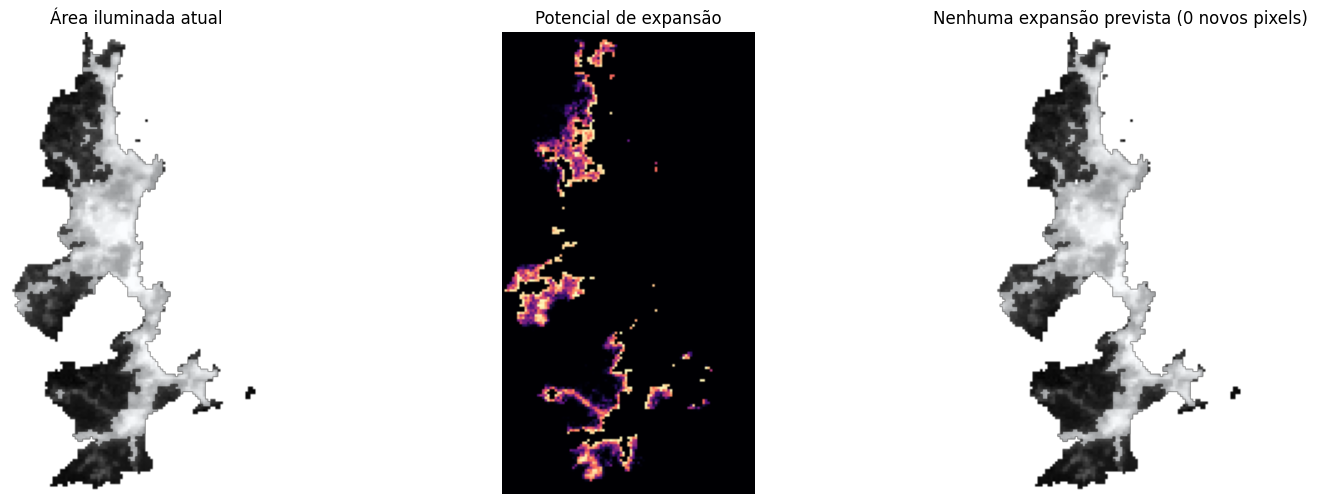

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def mostrar_mapa_expansao_prevista(regiao, meses_a_frente=12):
    resultado_espacial = prever_expansao_espacial_regiao(regiao, meses_a_frente=meses_a_frente)

    print("Região:", resultado_espacial["regiao"])
    print("Data prevista:", resultado_espacial["data_prevista"].date())
    
    pixels_atuais = resultado_espacial["pixels_atuais"]
    pixels_previstos = resultado_espacial["pixels_previstos"]
    print("Pixels iluminados atuais:", pixels_atuais)
    print("Pixels iluminados previstos:", pixels_previstos)
    
    # ISOLAR APENAS O CRESCIMENTO: Pega o que está na expansão, mas subtrai o que já existe
    mascara_atual = resultado_espacial["mascara_atual"]
    mascara_expansao = resultado_espacial["mascara_expansao"]
    apenas_novos = mascara_expansao & ~mascara_atual
    qtd_novos = int(apenas_novos.sum())
    
    print("NOVOS pixels de expansão:", qtd_novos)

    figura, eixos = plt.subplots(1, 3, figsize=(18, 6))

    # [GRÁFICO 1] Área Atual
    eixos[0].imshow(resultado_espacial["imagem_visual"], cmap="gray")
    eixos[0].imshow(np.where(mascara_atual, 1, np.nan), cmap="Blues", alpha=0.5)
    eixos[0].set_title("Área iluminada atual")

    # [GRÁFICO 2] Potencial
    eixos[1].imshow(resultado_espacial["probabilidade_expansao"], cmap="magma")
    eixos[1].set_title("Potencial de expansão")

    # [GRÁFICO 3] Expansão Isolada
    eixos[2].imshow(resultado_espacial["imagem_visual"], cmap="gray")
    
    # Pinta a cidade atual de azul
    eixos[2].imshow(np.where(mascara_atual, 1, np.nan), cmap="Blues", alpha=0.5)
    
    # Se houver crescimento, pinta APENAS os novos pixels de Vermelho Sólido
    if qtd_novos > 0:
        mapa_vermelho = ListedColormap(['red'])
        eixos[2].imshow(np.where(apenas_novos, 1, np.nan), cmap=mapa_vermelho, alpha=1.0)
        eixos[2].set_title(f"Expansão prevista ({qtd_novos} novos pixels em Vermelho)")
    else:
        # Se o modelo previu retração ou 0 crescimento, avisa no título
        eixos[2].set_title("Nenhuma expansão prevista (0 novos pixels)")

    for eixo in eixos:
        eixo.axis("off")

    plt.show()

    return resultado_espacial

# Executar a função
REGIAO_ESCOLHIDA = sorted(tabela_metricas_modelo["regiao"].unique())[0]
resultado_expansao_espacial = mostrar_mapa_expansao_prevista(REGIAO_ESCOLHIDA, meses_a_frente=12)   

## 20. Visualização dos modelos

Florianopolis: o modelo temporal agora é um MLPRegressor.
Redes neurais MLP não possuem feature_importances_ como RandomForest.
Para avaliar o modelo temporal, use o gráfico observado x previsto e a tabela de validação.


C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

,feature,importancia
0,luz_t0,0.506484
1,densidade_vizinhanca_t0,0.302488
2,distancia_borda_t0,0.123706
3,delta_luz_t0,0.067321


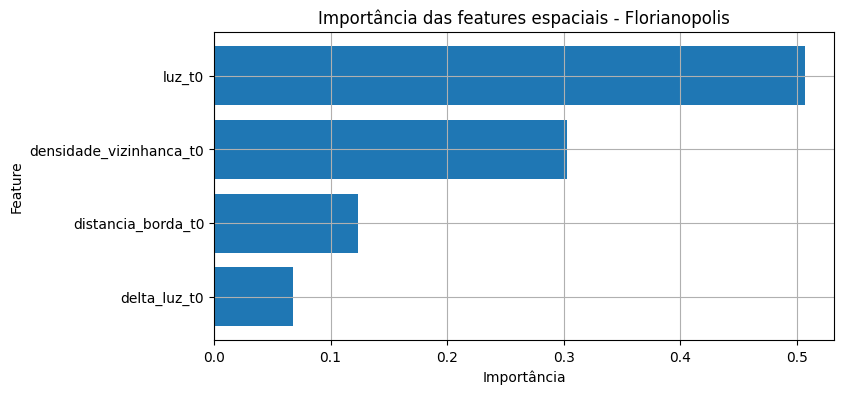

In [ ]:
def visualizar_importancia_modelo_temporal(regiao):
    modelo_temporal = modelos_por_regiao.get(regiao)

    if modelo_temporal is None:
        print(f"{regiao}: modelo temporal não encontrado.")
        return

    print(f"{regiao}: o modelo temporal agora é um MLPRegressor.")
    print("Redes neurais MLP não possuem feature_importances_ como RandomForest.")
    print("Para avaliar o modelo temporal, use o gráfico observado x previsto e a tabela de validação.")


def visualizar_importancia_modelo_espacial(regiao):
    modelo_espacial = treinar_modelo_espacial_regiao(regiao)

    if modelo_espacial is None:
        print(f"{regiao}: modelo espacial não encontrado.")
        return

    tabela_importancia = pd.DataFrame({
        "feature": COLUNAS_ENTRADA_ESPACIAL,
        "importancia": modelo_espacial.feature_importances_
    }).sort_values("importancia", ascending=True)

    display(tabela_importancia.sort_values("importancia", ascending=False))

    plt.figure(figsize=(8, 4))
    plt.barh(tabela_importancia["feature"], tabela_importancia["importancia"])
    plt.title(f"Importância das features espaciais - {regiao}")
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.show()


visualizar_importancia_modelo_temporal("Florianopolis")
visualizar_importancia_modelo_espacial("Florianopolis")


## 21. Visualização de uma árvore espacial

A árvore temporal deixa de existir porque a previsão temporal usa uma rede neural MLP. A árvore abaixo continua sendo do modelo espacial RandomForestClassifier.

Florianopolis: o modelo temporal agora é um MLPRegressor.
MLPRegressor é uma rede neural e não possui árvores para visualizar.


C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\bielc\AppData\Local\Temp\ipykernel_27868\1845599134.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

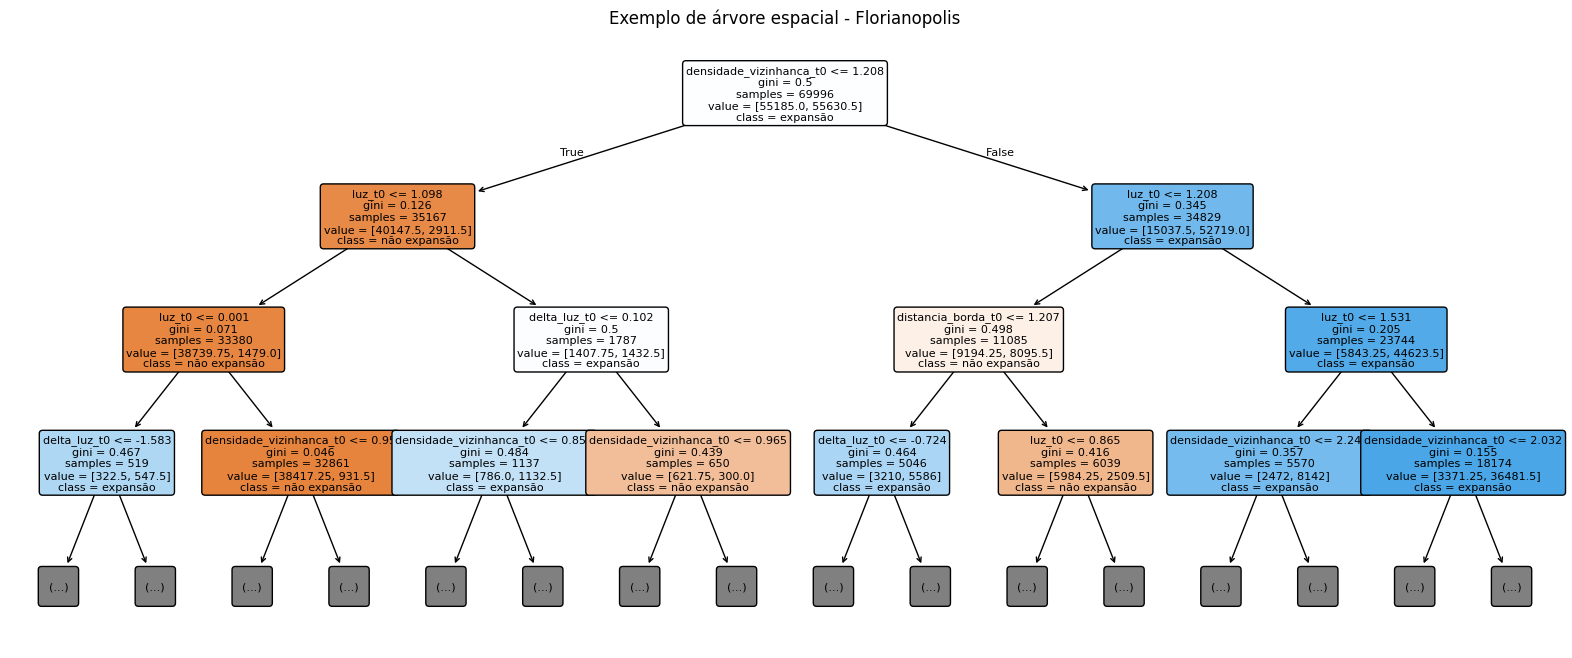

In [ ]:
def visualizar_arvore_temporal(regiao, indice_arvore=0, profundidade=3):
    modelo_temporal = modelos_por_regiao.get(regiao)

    if modelo_temporal is None:
        print(f"{regiao}: modelo temporal não encontrado.")
        return

    print(f"{regiao}: o modelo temporal agora é um MLPRegressor.")
    print("MLPRegressor é uma rede neural e não possui árvores para visualizar.")


def visualizar_arvore_espacial(regiao, indice_arvore=0, profundidade=3):
    modelo_espacial = treinar_modelo_espacial_regiao(regiao)

    if modelo_espacial is None:
        print(f"{regiao}: modelo espacial não encontrado.")
        return

    arvore = modelo_espacial.estimators_[indice_arvore]

    plt.figure(figsize=(20, 8))
    plot_tree(
        arvore,
        feature_names=COLUNAS_ENTRADA_ESPACIAL,
        class_names=["não expansão", "expansão"],
        filled=True,
        rounded=True,
        max_depth=profundidade,
        fontsize=8
    )
    plt.title(f"Exemplo de árvore espacial - {regiao}")
    plt.show()


visualizar_arvore_temporal("Florianopolis")
visualizar_arvore_espacial("Florianopolis")
